In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dataclasses import dataclass
import multiprocessing as mp

# Performance as time goes on (Fig. 4)

In [11]:
@dataclass
class Record:
    exec_per_time: float
    p_emp_min: float
    data_done: pd.DataFrame


def discovery(
    record_obj: Record, t_m: float, target: str, debug: bool = False
) -> float:
    exec_at_t = int(t_m * record_obj.exec_per_time)
    if exec_at_t == 0:
        return 0
    # find the row where #execs is the closest to exec_at_t
    for i, row in record_obj.data_done.iterrows():
        if row["#execs"] > exec_at_t:
            break
    row = record_obj.data_done.iloc[i - 1]
    assert row["done"]
    if debug:
        print(row)
    if target == "GT":
        ret = row["#singletons"] / exec_at_t
    elif target == "Chao":
        ret = row["#sglt_clusts"] / exec_at_t
    elif target == "emp":
        ret = row["#foundnew"] / exec_at_t
        if ret == 0:
            ret = record_obj.p_emp_min
    else:
        raise ValueError(f"Invalid target: {target}")
    return ret

In [12]:
def get_record_obj(data_path):
    data = pd.read_csv(data_path, sep=", ")
    data["done"] = data["done"].astype(bool)
    data["time"] = data["time"] / 1000 / 60
    # if #singletons or #sglt_clusts is 0, set it to 1
    data["#singletons"] = data["#singletons"].replace(0, 1)
    data["#sglt_clusts"] = data["#sglt_clusts"].replace(0, 1)
    data_done = data[data["done"]]
    # 24 hours
    data_done = data_done[data_done["time"] < 24 * 60]
    # add one more row with 24 hours
    row_last = data_done.iloc[-1]
    row_last_plus1 = data.iloc[data_done.index[-1] + 1]
    row_24h = {
        "time": 24 * 60.0,
        "#execs": row_last["#execs"]
        + (row_last_plus1["#execs"] - row_last["#execs"])
        * (24 * 60 - row_last["time"])
        / (row_last_plus1["time"] - row_last["time"]),
        "#covered": row_last["#covered"],
        "#singletons": row_last["#singletons"],
        "#sglt_clusts": row_last["#sglt_clusts"],
        "#foundnew": row_last["#foundnew"],
        "done": True,
        "update?": False,
    }
    data_done = pd.concat(
        [data_done, pd.DataFrame([row_24h])], ignore_index=True
    )
    data_done["#execs"] = data_done["#execs"].astype(int)

    exec_per_time = data_done.iloc[-1]["#execs"] / data_done.iloc[-1]["time"]
    p_emps = data_done["#foundnew"] / data_done["#execs"]
    p_emps_min = np.min(p_emps[p_emps > 0])

    return Record(exec_per_time, p_emps_min, data_done)

In [13]:
def get_plot_df(
    record_obj: Record, x_scale: str, id: str
) -> pd.DataFrame:
    if x_scale == "lin":
        x = np.linspace(0, 24 * 60, 1000)
    elif x_scale == "log":
        x = np.logspace(0, np.log10(24 * 60), 1000)
    else:
        raise ValueError(f"Invalid x_scale: {x_scale}")
    print(f"{id=} processing start", flush=True, end="\r")
    y_emp = [discovery(record_obj, t, "emp") for t in x]
    print(f"{id=} emp done", flush=True, end="\r")
    y_GT = [discovery(record_obj, t, "GT") for t in x]
    print(f"{id=} GT done", flush=True, end="\r")
    y_Chao = [discovery(record_obj, t, "Chao") for t in x]
    print(f"{id=} Chao done", flush=True, end="\r")
    plot_df = pd.DataFrame(
        {"time": x, "p_emp": y_emp, "p_GT": y_GT, "p_Chao": y_Chao}
    )
    plot_df = plot_df.melt(
        id_vars=["time"], value_vars=["p_emp", "p_GT", "p_Chao"], value_name="Pr", var_name="Esti"
    )
    plot_df["Dur"] = 1 / plot_df["Pr"] / record_obj.exec_per_time
    print(f"{id=} done", flush=True)
    plot_df["id"] = id
    return plot_df

In [14]:
get_record_obj("../data/records/record-freetype2-1.csv")

/var/folders/v9/wc5dh1fd691947y71hyt_2280000gn/T/ipykernel_61845/1366183030.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(data_path, sep=", ")


Record(exec_per_time=7662.899305555556, p_emp_min=5.806693936395512e-06, data_done=             time    #execs  #covered  #singletons  #sglt_clusts  #foundnew  \
0        0.000067         1       914          914             1          1   
1        0.000083         2       959           49             2          2   
2        0.000100         3      1629          698             3          1   
3        0.000117         4      1629           36             3          3   
4        0.000133         5      1637           40             4          4   
...           ...       ...       ...          ...           ...        ...   
1339  1351.961133  10199582      5122          229            46         62   
1340  1397.340167  10632576      5126          232            47         72   
1341  1403.605967  10690689      5126          228            46         73   
1342  1405.721733  10709981      5127          229            47         72   
1343  1440.000000  11034575      5127          2

In [15]:
is_generate = False

#### freetype2

In [16]:
if is_generate:
    proj = "freetype2"
    idcs = range(1, 21)
    with mp.Pool(mp.cpu_count()) as pool:
        record_objs = pool.map(
            get_record_obj,
            [f"../data/records/record-{proj}-{i}.csv" for i in idcs],
        )
    params = [
        (record_obj, "log", str(idx))
        for idx, record_obj in enumerate(record_objs, 1)
    ]
    with mp.Pool(mp.cpu_count()) as pool:
        plot_dfs = pool.starmap(get_plot_df, params)
    plot_df = pd.concat(plot_dfs, ignore_index=True)
    plot_df["Esti"] = plot_df["Esti"].replace(
        {
            "p_emp": r"$\hat{T}_{emp}$",
            "p_GT": r"$\hat{T}_{GT}$",
            "p_Chao": r"$\hat{T}_{St}$",
        }
    )
    # save plot_df
    plot_df.to_csv("../data/freetype2.csv", index=False)

In [17]:
# load plot_df
plot_df = pd.read_csv("../data/freetype2.csv")

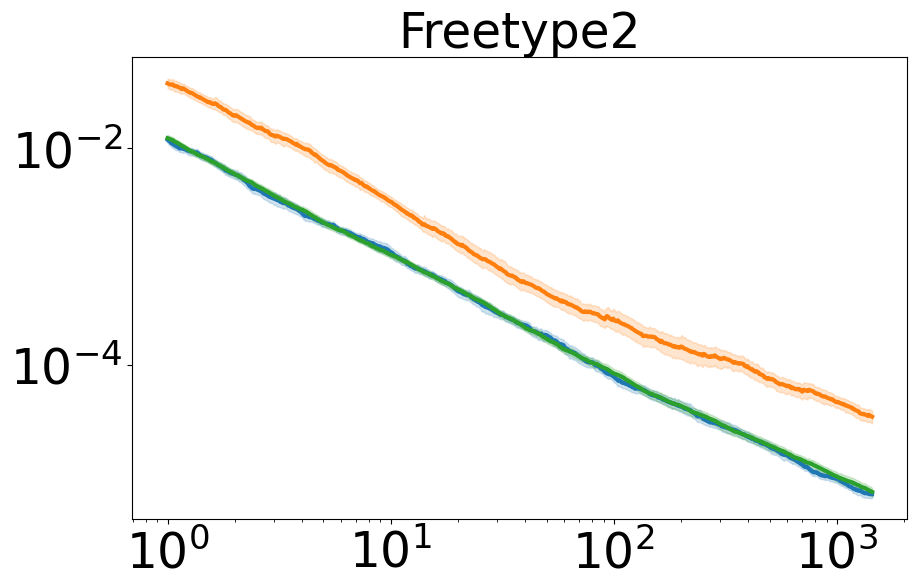

In [18]:
# Probability plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Pr", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Freetype2", fontsize=35)
plt.savefig("../figs/freetype2-mm.pdf", bbox_inches="tight")
plt.show()

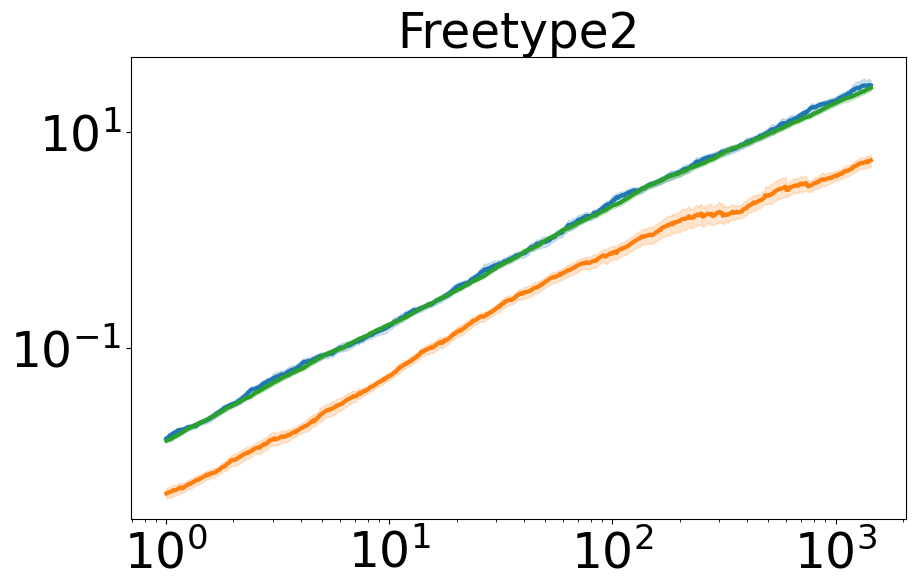

In [19]:
# Duration plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Dur", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Freetype2", fontsize=35)
plt.savefig("../figs/freetype2-time.pdf", bbox_inches="tight")
plt.show()

#### jsoncpp

In [20]:
if is_generate:
    proj = "jsoncpp"
    idcs = range(1, 21)
    with mp.Pool(mp.cpu_count()) as pool:
        record_objs = pool.map(
            get_record_obj,
            [f"../data/records/record-{proj}-{i}.csv" for i in idcs],
        )
    params = [
        (record_obj, "log", str(idx))
        for idx, record_obj in enumerate(record_objs, 1)
    ]
    with mp.Pool(mp.cpu_count()) as pool:
        plot_dfs = pool.starmap(get_plot_df, params)
    plot_df = pd.concat(plot_dfs, ignore_index=True)
    plot_df["Esti"] = plot_df["Esti"].replace(
        {
            "p_emp": r"$\hat{T}_{emp}$",
            "p_GT": r"$\hat{T}_{GT}$",
            "p_Chao": r"$\hat{T}_{St}$",
        }
    )
    # save plot_df
    plot_df.to_csv("../data/jsoncpp.csv", index=False)

In [22]:
# load plot_df
plot_df = pd.read_csv("../data/jsoncpp.csv")

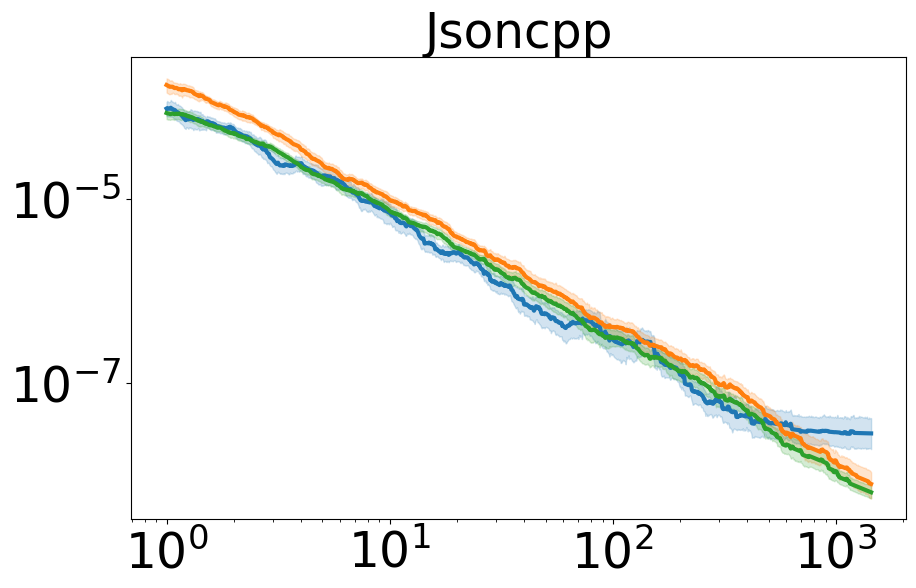

In [23]:
# Probability plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Pr", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Jsoncpp", fontsize=35)
plt.savefig("../figs/jsoncpp-mm.pdf", bbox_inches="tight")
plt.show()

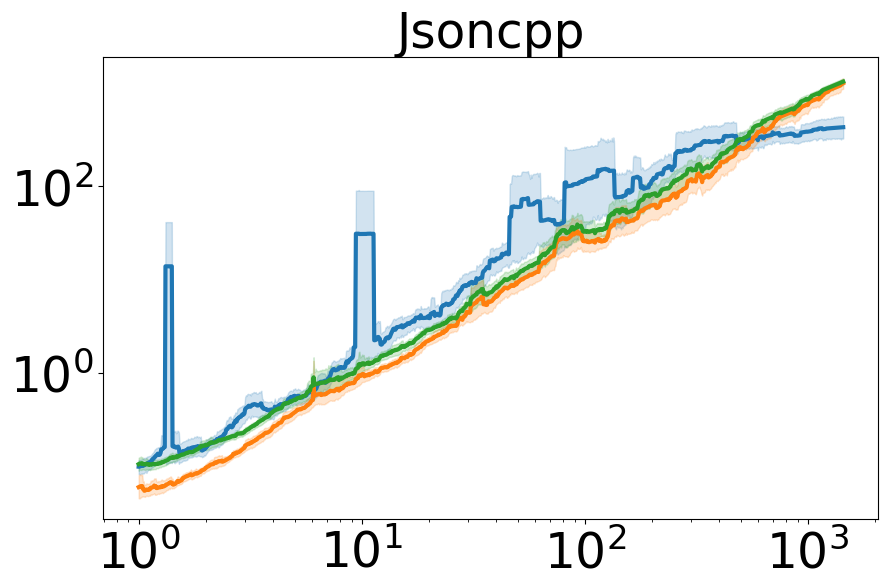

In [24]:
# Duration plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Dur", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Jsoncpp", fontsize=35)
plt.savefig("../figs/jsoncpp-time.pdf", bbox_inches="tight")
plt.show()

#### libjpeg

In [25]:
if is_generate:
    proj = "libjpeg"
    idcs = range(1, 21)
    with mp.Pool(mp.cpu_count()) as pool:
        record_objs = pool.map(
            get_record_obj,
            [f"../data/records/record-{proj}-{i}.csv" for i in idcs],
        )
    params = [
        (record_obj, "log", str(idx))
        for idx, record_obj in enumerate(record_objs, 1)
    ]
    with mp.Pool(mp.cpu_count()) as pool:
        plot_dfs = pool.starmap(get_plot_df, params)
    plot_df = pd.concat(plot_dfs, ignore_index=True)
    plot_df["Esti"] = plot_df["Esti"].replace(
        {
            "p_emp": r"$\hat{T}_{emp}$",
            "p_GT": r"$\hat{T}_{GT}$",
            "p_Chao": r"$\hat{T}_{St}$",
        }
    )
    plot_df
    # save plot_df
    plot_df.to_csv("../data/libjpeg.csv", index=False)

In [26]:
# load plot_df
plot_df = pd.read_csv("../data/libjpeg.csv")

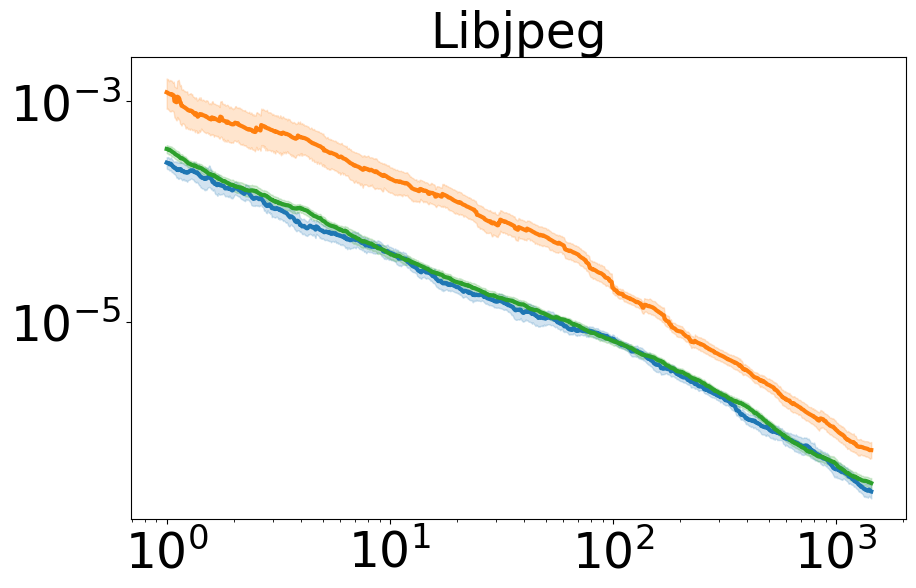

In [27]:
# Probability plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Pr", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Libjpeg", fontsize=35)
plt.savefig("../figs/libjpeg-mm.pdf", bbox_inches="tight")
plt.show()

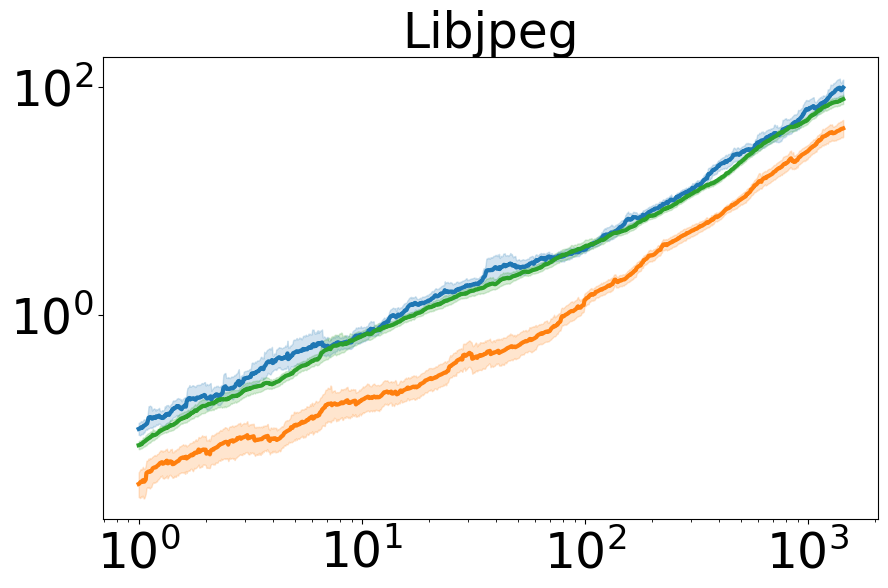

In [28]:
# Duration plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Dur", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Libjpeg", fontsize=35)
plt.savefig("../figs/libjpeg-time.pdf", bbox_inches="tight")
plt.show()

#### sqlite3

In [29]:
if is_generate:
    proj = "sqlite3"
    idcs = range(1, 21)
    with mp.Pool(mp.cpu_count()) as pool:
        record_objs = pool.map(
            get_record_obj,
            [f"../data/records/record-{proj}-{i}.csv" for i in idcs],
        )
    params = [
        (record_obj, "log", str(idx))
        for idx, record_obj in enumerate(record_objs, 1)
    ]
    with mp.Pool(mp.cpu_count()) as pool:
        plot_dfs = pool.starmap(get_plot_df, params)
    plot_df = pd.concat(plot_dfs, ignore_index=True)
    plot_df["Esti"] = plot_df["Esti"].replace(
        {
            "p_emp": r"$\hat{T}_{emp}$",
            "p_GT": r"$\hat{T}_{GT}$",
            "p_Chao": r"$\hat{T}_{St}$",
        }
    )
    # save plot_df
    plot_df.to_csv("../data/sqlite3.csv", index=False)

In [30]:
# load plot_df
plot_df = pd.read_csv("../data/sqlite3.csv")

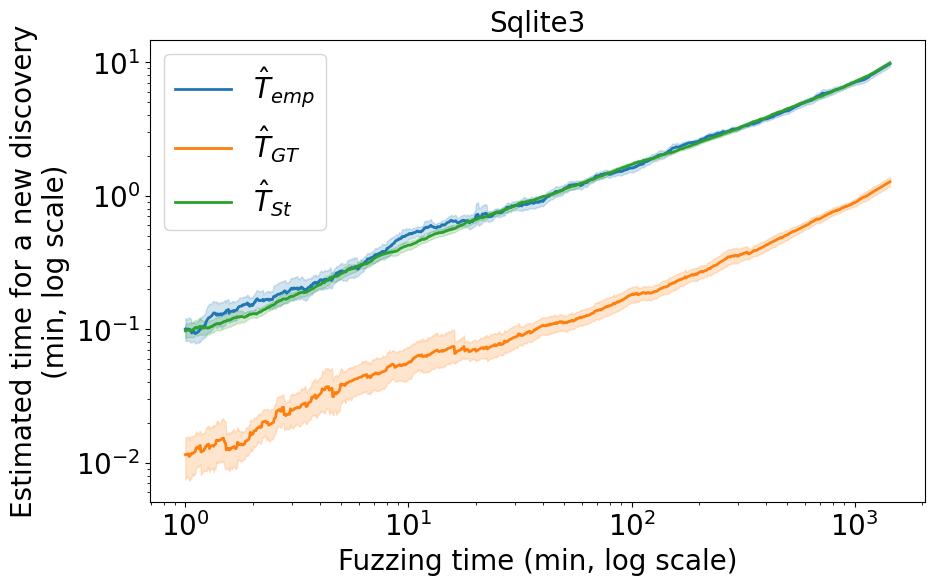

In [31]:
# Duration plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Dur", hue="Esti", data=plot_df, ax=ax, linewidth=2)
ax.set_ylabel(
    "Estimated time for a new discovery\n(min, log scale)", fontsize=20
)
ax.set_xlabel("Fuzzing time (min, log scale)", fontsize=20)
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=20)
ax.legend(fontsize=20)
ax.set_title("Sqlite3", fontsize=20)
plt.savefig("../figs/sqlite3-time.pdf", bbox_inches="tight")
plt.show()

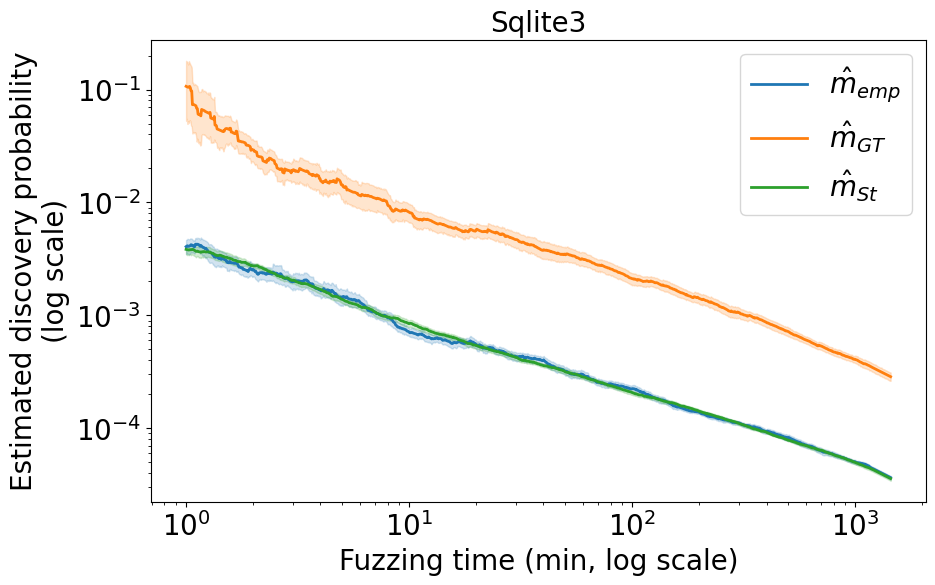

In [32]:
# Probability plot
fig, ax = plt.subplots(figsize=(10, 6))
plot_df["Esti"] = plot_df["Esti"].replace(
    {
        r"$\hat{T}_{emp}$": r"$\hat{m}_{emp}$",
        r"$\hat{T}_{GT}$": r"$\hat{m}_{GT}$",
        r"$\hat{T}_{St}$": r"$\hat{m}_{St}$",
    }
)
sns.lineplot(x="time", y="Pr", hue="Esti", data=plot_df, ax=ax, linewidth=2)
ax.set_ylabel("Estimated discovery probability\n(log scale)", fontsize=20)
ax.set_xlabel("Fuzzing time (min, log scale)", fontsize=20)
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=20)
ax.legend(fontsize=20)
ax.set_title("Sqlite3", fontsize=20)
plt.savefig("../figs/sqlite3-mm.pdf", bbox_inches="tight")
plt.show()

#### libxml2

In [33]:
if is_generate:
    proj = "libxml2"
    idcs = range(1, 21)
    with mp.Pool(mp.cpu_count()) as pool:
        record_objs = pool.map(
            get_record_obj,
            [f"../data/records/record-{proj}-{i}.csv" for i in idcs],
        )
    params = [
        (record_obj, "log", str(idx))
        for idx, record_obj in enumerate(record_objs, 1)
    ]
    with mp.Pool(mp.cpu_count()) as pool:
        plot_dfs = pool.starmap(get_plot_df, params)
    plot_df = pd.concat(plot_dfs, ignore_index=True)
    plot_df["Esti"] = plot_df["Esti"].replace(
        {
            "p_emp": r"$\hat{T}_{emp}$",
            "p_GT": r"$\hat{T}_{GT}$",
            "p_Chao": r"$\hat{T}_{St}$",
        }
    )
    # save plot_df
    plot_df.to_csv("../data/libxml2.csv", index=False)

In [34]:
# load plot_df
plot_df = pd.read_csv("../data/libxml2.csv")

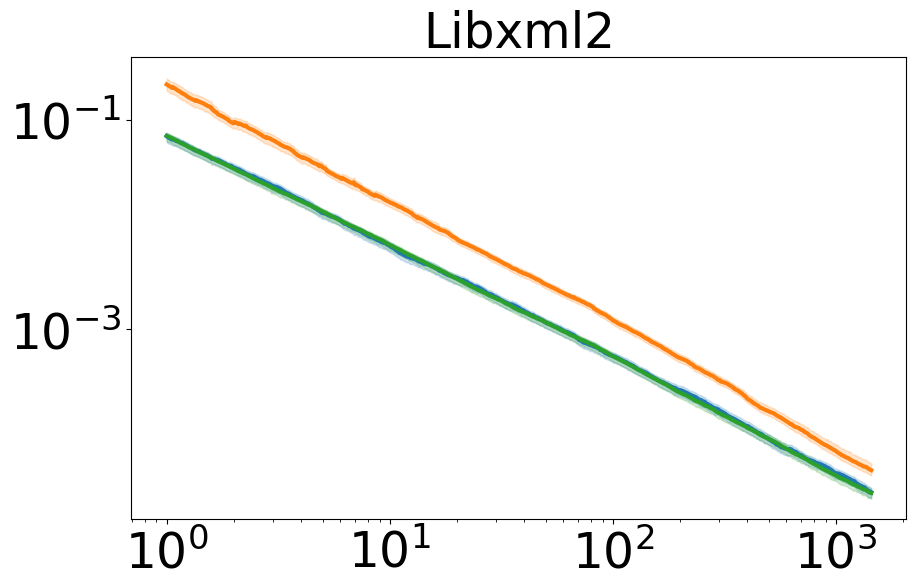

In [35]:
# Probability plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Pr", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Libxml2", fontsize=35)
plt.savefig("../figs/libxml2-mm.pdf", bbox_inches="tight")
plt.show()

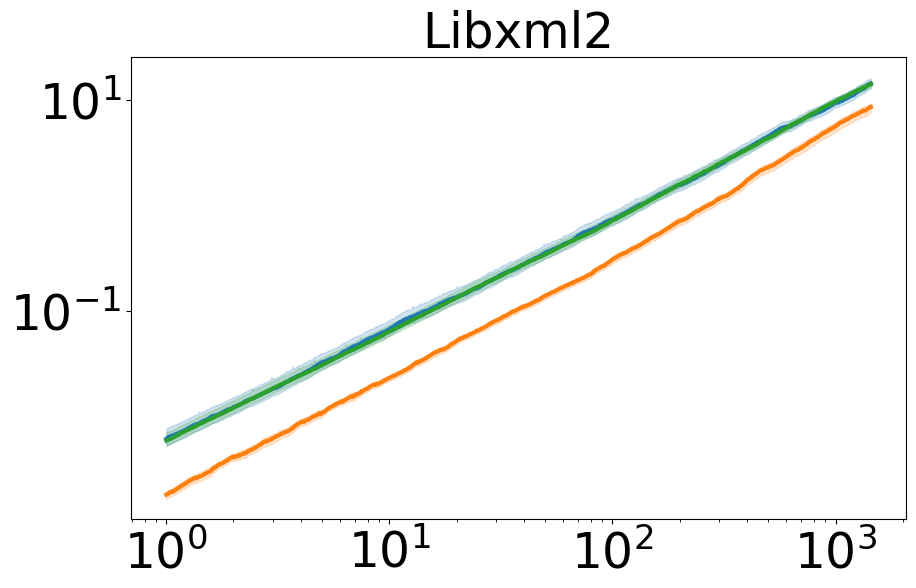

In [36]:
# Duration plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(x="time", y="Dur", hue="Esti", data=plot_df, ax=ax, linewidth=3)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_xscale("log")
ax.set_yscale("log")
ax.tick_params(axis="both", labelsize=35)
ax.get_legend().remove()
ax.set_title("Libxml2", fontsize=35)
plt.savefig("../figs/libxml2-time.pdf", bbox_inches="tight")
plt.show()

# Overall performance (Sec. 6.1)

In [37]:
data = []
for subject in ["sqlite3", "libxml2", "libjpeg", "freetype2", "jsoncpp"]:
    plot_df = pd.read_csv(f"../data/{subject}.csv")
    sub_df = plot_df[["id", "time", "Esti", "Pr"]]
    for id in range(1, 21):
        sub_sub_df = sub_df[sub_df["id"] == id].copy()
        sub_sub_df["Esti"] = sub_sub_df["Esti"].replace(
            {
                r"$\hat{T}_{emp}$": "emp",
                r"$\hat{T}_{GT}$": "GT",
                r"$\hat{T}_{St}$": "Chao",
            }
        )
        sub_sub_df = (
            sub_sub_df.pivot(index="time", columns="Esti", values="Pr")
            .reset_index()
            .rename_axis(None, axis=1)
        )
        emp_avg = sub_sub_df["emp"].mean()
        err_gt = np.abs(sub_sub_df["GT"] - sub_sub_df["emp"])
        err_gt_avg = err_gt.mean()
        err_chao = np.abs(sub_sub_df["Chao"] - sub_sub_df["emp"])
        err_chao_avg = err_chao.mean()
        rel_err_gt = err_gt / sub_sub_df["emp"]
        rel_err_gt_avg = rel_err_gt.mean()
        rel_err_chao = err_chao / sub_sub_df["emp"]
        rel_err_chao_avg = rel_err_chao.mean()
        data.append(
            {
                "subject": subject,
                "emp_avg": emp_avg,
                "err_gt_avg": err_gt_avg,
                "rel_err_gt_avg": rel_err_gt_avg,
                "err_chao_avg": err_chao_avg,
                "rel_err_chao_avg": rel_err_chao_avg,
            }
        )
data_df = pd.DataFrame(data)
data_df["ratio"] = data_df["rel_err_chao_avg"] / data_df["rel_err_gt_avg"]
data_df

,subject,emp_avg,err_gt_avg,rel_err_gt_avg,err_chao_avg,rel_err_chao_avg,ratio
0,sqlite3,0.000717,0.003922,9.352767,0.000236,0.232724,0.024883
1,sqlite3,0.000922,0.013720,10.161461,0.000303,0.237366,0.023359
2,sqlite3,0.000841,0.011582,12.109856,0.000258,0.239162,0.019749
3,sqlite3,0.000833,0.007802,9.307971,0.000223,0.214919,0.023090
4,sqlite3,0.000900,0.008985,8.950696,0.000229,0.209316,0.023385
...,...,...,...,...,...,...,...
95,jsoncpp,0.000012,0.000014,54.537500,0.000009,33.910870,0.621790
96,jsoncpp,0.000009,0.000020,1.360814,0.000005,0.727019,0.534254
97,jsoncpp,0.000012,0.000015,1.037917,0.000007,0.756255,0.728628
98,jsoncpp,0.000010,0.000016,1.962224,0.000005,1.221447,0.622481


In [38]:
# average
data_df_avg = data_df.groupby("subject").mean().reset_index()
data_df_avg

,subject,emp_avg,err_gt_avg,rel_err_gt_avg,err_chao_avg,rel_err_chao_avg,ratio
0,freetype2,0.001529,0.003815,2.634066,0.000249,0.200585,0.078763
1,jsoncpp,0.000013,0.000011,5.868143,0.000006,3.865352,0.659866
2,libjpeg,0.000046,0.000157,3.564005,0.000019,0.408345,0.138261
3,libxml2,0.009332,0.016835,1.817316,0.000935,0.115530,0.081873
4,sqlite3,0.000852,0.009557,10.012222,0.000267,0.227508,0.023272


# The absolute error of the discovery probability estimation for the subjects from FuzzBench across different time intervals during fuzzing (Table 4)

In [43]:
time_ranges = [(0, 10), (10, 60), (60, 360), (360, 720), (720, 1440)]
data = []
for subject in ["sqlite3", "libxml2", "libjpeg", "freetype2", "jsoncpp"]:
    plot_df = pd.read_csv(f"../data/{subject}.csv")
    for time_range in time_ranges:
        sub_df = plot_df[
            (plot_df["time"] >= time_range[0])
            & (plot_df["time"] <= time_range[1])
        ][["id", "time", "Esti", "Dur"]]
        for id in range(1, 21):
            sub_sub_df = sub_df[sub_df["id"] == id].copy()
            sub_sub_df["Esti"] = sub_sub_df["Esti"].replace(
                {
                    r"$\hat{T}_{emp}$": "emp",
                    r"$\hat{T}_{GT}$": "GT",
                    r"$\hat{T}_{St}$": "Chao",
                }
            )
            sub_sub_df = (
                sub_sub_df.pivot(index="time", columns="Esti", values="Dur")
                .reset_index()
                .rename_axis(None, axis=1)
            )
            emp_avg = sub_sub_df["emp"].mean()
            err_gt = np.abs(sub_sub_df["GT"] - sub_sub_df["emp"])
            err_gt_avg = err_gt.mean()
            err_chao = np.abs(sub_sub_df["Chao"] - sub_sub_df["emp"])
            err_chao_avg = err_chao.mean()
            rel_err_gt = err_gt / sub_sub_df["emp"]
            rel_err_gt_avg = rel_err_gt.mean()
            rel_err_chao = err_chao / sub_sub_df["emp"]
            rel_err_chao_avg = rel_err_chao.mean()
            data.append(
                {
                    "subject": subject,
                    "dur": time_range,
                    "emp_avg": emp_avg,
                    "err_gt_avg": err_gt_avg,
                    "rel_err_gt_avg": rel_err_gt_avg,
                    "err_chao_avg": err_chao_avg,
                    "rel_err_chao_avg": rel_err_chao_avg,
                }
            )
data_df = pd.DataFrame(data)
data_df

,subject,dur,emp_avg,err_gt_avg,rel_err_gt_avg,err_chao_avg,rel_err_chao_avg
0,sqlite3,"(0, 10)",0.205941,0.144020,0.703636,0.065833,0.312965
1,sqlite3,"(0, 10)",0.199454,0.175303,0.892355,0.065332,0.368835
2,sqlite3,"(0, 10)",0.243280,0.229803,0.930922,0.088798,0.393868
3,sqlite3,"(0, 10)",0.236051,0.202478,0.861723,0.056272,0.275221
4,sqlite3,"(0, 10)",0.166336,0.151275,0.894408,0.035301,0.237929
...,...,...,...,...,...,...,...
495,jsoncpp,"(720, 1440)",275.058578,760.628833,2.765334,760.628833,2.765334
496,jsoncpp,"(720, 1440)",256.527124,59.927410,0.233691,268.809204,1.061581
497,jsoncpp,"(720, 1440)",597.170184,427.134459,0.715264,410.249159,0.686989
498,jsoncpp,"(720, 1440)",259.356887,100.557359,0.387718,258.486819,0.996645


In [44]:
data_df_melt = data_df.melt(
    id_vars=["subject", "dur"],
    value_vars=[
        "emp_avg",
        "err_gt_avg",
        "rel_err_gt_avg",
        "err_chao_avg",
        "rel_err_chao_avg",
    ],
    var_name="metric",
)
data_df_pivot = data_df_melt.pivot_table(
    index=["subject", "metric"],
    columns="dur",
    values="value",
    aggfunc="mean",
)
data_df_pivot = data_df_pivot.reindex(
    ["sqlite3", "libxml2", "libjpeg", "freetype2", "jsoncpp"],
    level=0,
)
data_df_pivot = data_df_pivot.reindex(
    [
        "emp_avg",
        "err_gt_avg",
        "rel_err_gt_avg",
        "err_chao_avg",
        "rel_err_chao_avg",
    ],
    level=1,
)
display(data_df_pivot)

dur                          (0, 10)   (10, 60)   (60, 360)  (360, 720)  \
subject   metric                                                          
sqlite3   emp_avg           0.228673   0.792250    2.223024    4.491937   
          err_gt_avg        0.199875   0.707993    1.989635    3.965501   
          rel_err_gt_avg    0.860608   0.884780    0.894419    0.880950   
          err_chao_avg      0.069709   0.160425    0.278802    0.526487   
          rel_err_chao_avg  0.335762   0.207481    0.135274    0.119262   
libxml2   emp_avg           0.025028   0.193485    1.310391    4.693359   
          err_gt_avg        0.016506   0.118991    0.726560    2.268183   
          rel_err_gt_avg    0.632163   0.588092    0.533793    0.452308   
          err_chao_avg      0.002797   0.021138    0.167482    0.571636   
          rel_err_chao_avg  0.106349   0.102855    0.123081    0.116147   
libjpeg   emp_avg           0.331241   1.690672    6.962771   27.232997   
          err_gt_avg        0.243395   1.337263    4.297144   15.961171   
          rel_err_gt_avg    0.686213   0.758269    0.631704    0.562148   
          err_chao_avg      0.133083   0.581135    1.561772    7.561078   
          rel_err_chao_avg  0.389560   0.316080    0.228962    0.258899   
freetype2 emp_avg           0.063248   0.525290    3.608350   10.498592   
          err_gt_avg        0.044223   0.313169    2.449224    7.895945   
          rel_err_gt_avg    0.697562   0.593442    0.650238    0.740513   
          err_chao_avg      0.011924   0.089220    0.763459    2.240359   
          rel_err_chao_avg  0.176209   0.167641    0.203411    0.211755   
jsoncpp   emp_avg           1.745757  17.380867  135.218486  329.263955   
          err_gt_avg        1.544009  13.864401  110.766891  202.907791   
          rel_err_gt_avg    0.504129   0.499696    0.877229    0.737456   
          err_chao_avg      1.525536  13.485069  106.303678  196.700126   
          rel_err_chao_avg  0.533071   0.488312    0.966025    0.804779   

dur                         (720, 1440)  
subject   metric                         
sqlite3   emp_avg              7.302582  
          err_gt_avg           6.370219  
          rel_err_gt_avg       0.870430  
          err_chao_avg         0.869877  
          rel_err_chao_avg     0.122318  
libxml2   emp_avg              9.751640  
          err_gt_avg           3.853682  
          rel_err_gt_avg       0.359007  
          err_chao_avg         1.512633  
          rel_err_chao_avg     0.155395  
libjpeg   emp_avg             63.518726  
          err_gt_avg          34.557746  
          rel_err_gt_avg       0.486025  
          err_chao_avg        20.283261  
          rel_err_chao_avg     0.298151  
freetype2 emp_avg             20.977731  
          err_gt_avg          16.843280  
          rel_err_gt_avg       0.796540  
          err_chao_avg         4.485678  
          rel_err_chao_avg     0.200059  
jsoncpp   emp_avg            391.216605  
          err_gt_avg         504.389879  
          rel_err_gt_avg       2.099473  
          err_chao_avg       549.570016  
          rel_err_chao_avg     2.269451

In [45]:
data_df_pivot = data_df_pivot.T
data_df_pivot = data_df_pivot.applymap(lambda x: f"{x:.2f}")
print(data_df_pivot.to_latex())

\begin{tabular}{llllllllllllllllllllllllll}
\toprule
subject & \multicolumn{5}{r}{sqlite3} & \multicolumn{5}{r}{libxml2} & \multicolumn{5}{r}{libjpeg} & \multicolumn{5}{r}{freetype2} & \multicolumn{5}{r}{jsoncpp} \\
metric & emp_avg & err_gt_avg & rel_err_gt_avg & err_chao_avg & rel_err_chao_avg & emp_avg & err_gt_avg & rel_err_gt_avg & err_chao_avg & rel_err_chao_avg & emp_avg & err_gt_avg & rel_err_gt_avg & err_chao_avg & rel_err_chao_avg & emp_avg & err_gt_avg & rel_err_gt_avg & err_chao_avg & rel_err_chao_avg & emp_avg & err_gt_avg & rel_err_gt_avg & err_chao_avg & rel_err_chao_avg \\
dur &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
(0, 10) & 0.23 & 0.20 & 0.86 & 0.07 & 0.34 & 0.03 & 0.02 & 0.63 & 0.00 & 0.11 & 0.33 & 0.24 & 0.69 & 0.13 & 0.39 & 0.06 & 0.04 & 0.70 & 0.01 & 0.18 & 1.75 & 1.54 & 0.50 & 1.53 & 0.53 \\
(10, 60) & 0.79 & 0.71 & 0.88 & 0.16 & 0.21 & 0.19 & 0.12 & 0.59 & 0.02 & 0.10 & 1.69 & 1.34 & 0.76 & 0.58 & 0.32 & 0.53 & 0.31

/var/folders/v9/wc5dh1fd691947y71hyt_2280000gn/T/ipykernel_61845/3175644830.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data_df_pivot = data_df_pivot.applymap(lambda x: f"{x:.2f}")


# The records from a single fuzzing run (Table 3)

## Libxml2

In [47]:
subject, id = "libxml2", 1
record_obj = get_record_obj(f"../data/records/record-{subject}-{id}.csv")
df = record_obj.data_done
df
target_times = [1, 10, 60, 360, 720]
data = []
for t in target_times:
    exec_at_t = int(t * record_obj.exec_per_time)
    if exec_at_t == 0:
        continue
    for i, row in df.iterrows():
        if row["#execs"] > exec_at_t:
            break
    row = df.iloc[i - 1]
    data.append(
        {
            "time": t,
            "#covered": row["#covered"],
            "#singletons": row["#singletons"],
            "#sglt_clusts": row["#sglt_clusts"],
            "#foundnew": row["#foundnew"],
        }
    )
data_df = pd.DataFrame(data)
data_df

/var/folders/v9/wc5dh1fd691947y71hyt_2280000gn/T/ipykernel_61845/1366183030.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(data_path, sep=", ")


,time,#covered,#singletons,#sglt_clusts,#foundnew
0,1,6356,511,195,164
1,10,7654,452,192,136
2,60,8319,325,152,153
3,360,8861,243,129,136
4,720,9048,235,133,100


## Jsoncpp

In [48]:
subject, id = "jsoncpp", 1
record_obj = get_record_obj(f"../data/records/record-{subject}-{id}.csv")
df = record_obj.data_done
df
target_times = [1, 10, 60, 360, 720]
data = []
for t in target_times:
    exec_at_t = int(t * record_obj.exec_per_time)
    if exec_at_t == 0:
        continue
    for i, row in df.iterrows():
        if row["#execs"] > exec_at_t:
            break
    row = df.iloc[i - 1]
    data.append(
        {
            "time": t,
            "#covered": row["#covered"],
            "#singletons": row["#singletons"],
            "#sglt_clusts": row["#sglt_clusts"],
            "#foundnew": row["#foundnew"],
        }
    )
data_df = pd.DataFrame(data)
data_df

/var/folders/v9/wc5dh1fd691947y71hyt_2280000gn/T/ipykernel_61845/1366183030.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  data = pd.read_csv(data_path, sep=", ")


,time,#covered,#singletons,#sglt_clusts,#foundnew
0,1,1131,8,5,25
1,10,1197,11,9,5
2,60,1211,4,3,4
3,360,1221,3,2,2
4,720,1224,1,1,2
